# Data Battle 2026 — Exploration des données
## Prédiction de la fin des alertes orage autour des aéroports

**Objectif de cette partie** : Explorer en profondeur les données pour comprendre la structure des orages, les patterns spatio-temporels, et identifier les features pertinentes pour la modélisation.

**Données** : 507 071 impacts de foudre sur 7 ans (2016–2022) dans un rayon de 50 km autour de 5 aéroports européens : Ajaccio, Bastia, Biarritz, Nantes, Pise.

**Variable cible** : `is_last_lightning_cloud_ground` — identifie le dernier éclair sol (CG) dans une alerte. L'alerte se termine 30 min après cet éclair.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
print('Librairies chargées ✓')

Librairies chargées ✓


---
## 1. Chargement et aperçu général

In [4]:
df = pd.read_csv('segment_alerts_all_airports_train.csv', parse_dates=['date'])

# Normalisation du timezone (UTC)
df['date'] = pd.to_datetime(df['date'], utc=True)

print(f'Shape : {df.shape}')
print(f'Période : {df["date"].min()} à {df["date"].max()}')
print(f'Aéroports : {df["airport"].unique()}')
df.head()

Shape : (507071, 13)
Période : 2016-01-02 01:10:41+00:00 → 2022-12-21 11:20:11+00:00
Aéroports : ['Ajaccio' 'Bastia' 'Biarritz' 'Nantes' 'Pise']


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [5]:
print('=== Types et valeurs manquantes ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info.to_string())

=== Types et valeurs manquantes ===
                                              dtype  non_null  null_%
lightning_id                                  int64    507071    0.00
lightning_airport_id                          int64    507071    0.00
date                            datetime64[ns, UTC]    507071    0.00
lon                                         float64    507071    0.00
lat                                         float64    507071    0.00
amplitude                                   float64    507071    0.00
maxis                                       float64    507071    0.00
icloud                                         bool    507071    0.00
dist                                        float64    507071    0.00
azimuth                                     float64    507071    0.00
airport                                      object    507071    0.00
airport_alert_id                            float64     56599   88.84
is_last_lightning_cloud_ground               object   

### Interprétation des valeurs manquantes

Deux colonnes présentent exactement **88.84% de valeurs manquantes** : `airport_alert_id` et `is_last_lightning_cloud_ground`. Ce n'est pas une coïncidence : ces colonnes ne sont renseignées que pour les éclairs **cloud-to-ground (CG) situés dans la zone d'alerte de 20 km**.

Cela révèle une structure fondamentale du dataset :
- **Zone contexte (20–30 km)** : éclairs IC et CG sans alerte associée → 88.84% des données (450 472 éclairs)
- **Zone alerte (< 20 km)** : uniquement des éclairs **CG** (contact au sol) avec un `airport_alert_id` → 11.16% des données (56 599 éclairs)

**Découverte clé** : La zone d'alerte ne contient que des éclairs CG (**0% d'éclairs IC**). Le système d'alerte Météorage est basé exclusivement sur les impacts nuage-sol, ce qui est logique opérationnellement (seuls les CG présentent un risque direct au sol). Les éclairs IC dans la zone 20–30 km restent utiles comme signal de l'activité orageuse globale.

In [6]:
df['zone'] = np.where(df['airport_alert_id'].notna(), 'Alerte (< 20 km)', 'Contexte (20–30 km)')

zone_counts = df['zone'].value_counts()
print(zone_counts)
print(f'\nProportion alerte : {zone_counts["Alerte (< 20 km)"] / len(df) * 100:.1f}%')

# Vérification : uniquement CG dans la zone d'alerte ?
df_alert = df[df['airport_alert_id'].notna()].copy()
df_alert['airport_alert_id'] = df_alert['airport_alert_id'].astype(int)
print(f'\nType d\'éclairs dans la zone alerte (< 20 km) :')
print(df_alert['icloud'].value_counts().rename({True: 'IC (intra-nuage)', False: 'CG (nuage-sol)'}))

zone
Contexte (20–50 km)    450472
Alerte (< 20 km)        56599
Name: count, dtype: int64

Proportion alerte : 11.2%

Type d'éclairs dans la zone alerte (< 20 km) :
icloud
CG (nuage-sol)    56599
Name: count, dtype: int64


**Confirmation** : La zone d'alerte (< 20 km) contient **100% d'éclairs CG** — les 56 599 éclairs de la zone alerte sont tous des impacts nuage-sol. L'objet de la modélisation est donc clair : prédire quand le **dernier éclair CG** va survenir dans la zone de 20 km.

---
## 2. Distribution par aéroport

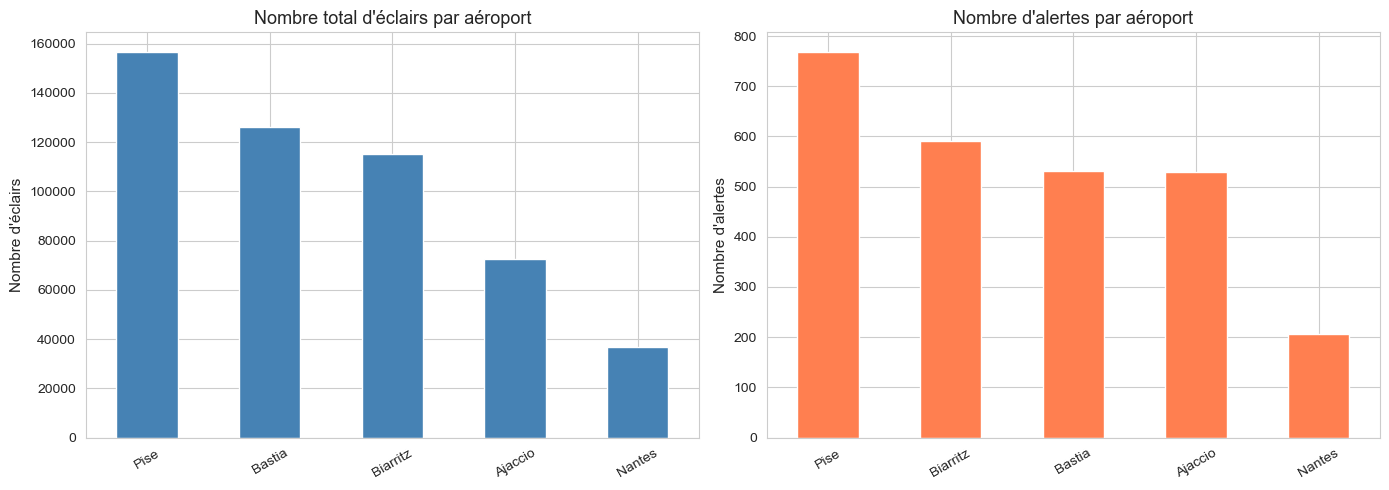

          n_eclairs  n_alertes  eclairs_par_alerte
airport                                           
Pise         156718        769               203.8
Bastia       125919        532               236.7
Biarritz     115191        590               195.2
Ajaccio       72501        530               136.8
Nantes        36742        206               178.4


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

airport_counts = df.groupby('airport').size().sort_values(ascending=False)
airport_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Nombre total d\'éclairs par aéroport')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nombre d\'éclairs')
axes[0].tick_params(axis='x', rotation=30)

alert_counts = df_alert.groupby('airport')['airport_alert_id'].nunique().sort_values(ascending=False)
alert_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Nombre d\'alertes par aéroport')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nombre d\'alertes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

stats_airport = df.groupby('airport').agg(
    n_eclairs=('lightning_id', 'count'),
    n_alertes=('airport_alert_id', 'nunique'),
).assign(eclairs_par_alerte=lambda x: (x['n_eclairs'] / x['n_alertes']).round(1))
print(stats_airport.sort_values('n_eclairs', ascending=False).to_string())

### Analyse par aéroport

Les 5 aéroports présentent des volumes très contrastés :
- **Pise** (Italie) : 156 718 éclairs, 769 alertes — le plus actif, contexte méditerranéen/continental
- **Bastia** (Corse) : 125 919 éclairs, 532 alertes, **237 éclairs/alerte** — orages particulièrement intenses
- **Biarritz** (Atlantique) : 115 191 éclairs, 590 alertes
- **Ajaccio** (Corse) : 72 501 éclairs, 530 alertes
- **Nantes** (Loire-Atlantique) : 36 742 éclairs, 206 alertes — le moins actif

**Bastia** se démarque nettement avec le ratio d'éclairs par alerte le plus élevé (~237), contre ~137 pour Ajaccio malgré une localisation géographique similaire (Corse). Cette hétérogénéité confirme que **le lieu est une feature discriminante** — les modèles doivent être capables de tenir compte de ces spécificités locales.

---
## 3. Analyse temporelle

In [8]:
df['year']   = df['date'].dt.year
df['month']  = df['date'].dt.month
df['hour']   = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['season'] = df['month'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
})
print('Features temporelles extraites ✓')

Features temporelles extraites ✓


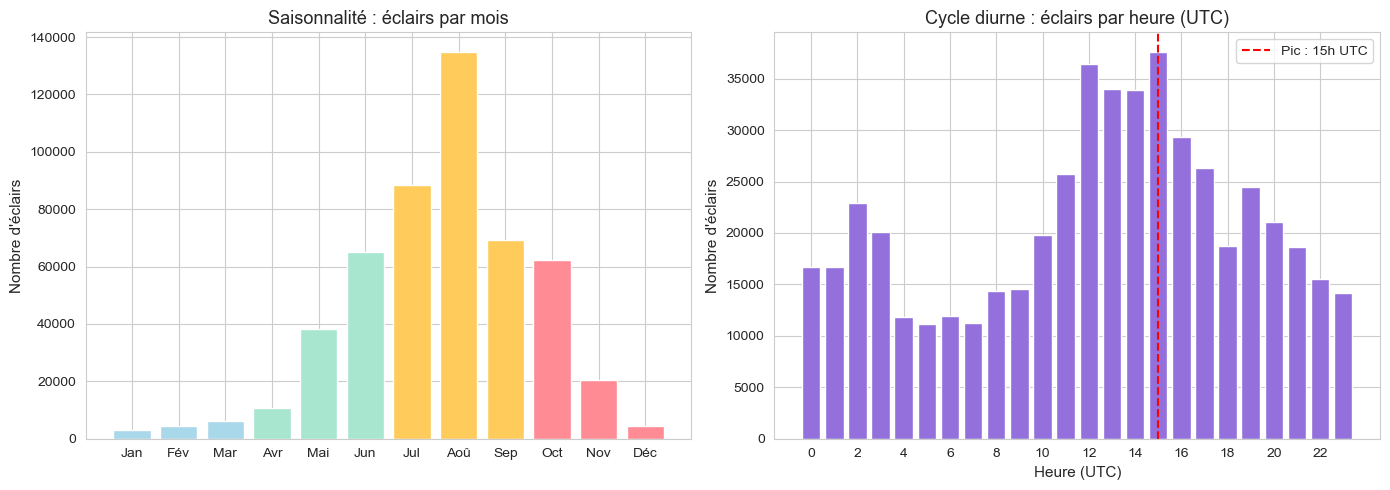

Distribution mensuelle :
  Jan :    2973 éclairs (0.6%)
  Fév :    4394 éclairs (0.9%)
  Mar :    6005 éclairs (1.2%)
  Avr :   10686 éclairs (2.1%)
  Mai :   38304 éclairs (7.6%)
  Jun :   65193 éclairs (12.9%)
  Jul :   88435 éclairs (17.4%)
  Aoû :  134901 éclairs (26.6%)
  Sep :   69215 éclairs (13.6%)
  Oct :   62127 éclairs (12.3%)
  Nov :   20322 éclairs (4.0%)
  Déc :    4516 éclairs (0.9%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby('month').size()
month_names = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
colors_m = ['#a8d8ea']*3 + ['#a8e6cf']*3 + ['#ffcc5c']*3 + ['#ff8b94']*3
axes[0].bar(range(1, 13), [monthly.get(m, 0) for m in range(1, 13)],
            color=colors_m, edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Saisonnalité : éclairs par mois')
axes[0].set_ylabel('Nombre d\'éclairs')

hourly = df.groupby('hour').size()
axes[1].bar(range(24), [hourly.get(h, 0) for h in range(24)],
            color='mediumpurple', edgecolor='white')
axes[1].axvline(15, color='red', linestyle='--', linewidth=1.5, label='Pic : 15h UTC')
axes[1].set_title('Cycle diurne : éclairs par heure (UTC)')
axes[1].set_xlabel('Heure (UTC)')
axes[1].set_ylabel('Nombre d\'éclairs')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.show()

print('Distribution mensuelle :')
for m, n in monthly.items():
    print(f'  {month_names[m-1]:4s}: {n:7d} éclairs ({n/len(df)*100:.1f}%)')

### Analyse temporelle

**Saisonnalité très marquée** : L'activité orageuse est massivement concentrée sur 5 mois (mai–septembre). **Août est le mois record** avec 134 901 éclairs (26.6% du total annuel). Janvier est le mois le plus calme avec seulement 2 973 éclairs (0.6%). L'été concentre donc l'essentiel de l'activité, ce qui est cohérent avec la convection thermique méditerranéenne et continentale.

**Cycle diurne classique** : Le pic d'activité se situe à **15h UTC** (16–17h heure locale), correspondant au maximum de convection thermique après le chauffage de la surface terrestre. Le minimum est à **5h UTC** (nuit). Ce pattern est typique des orages convectifs estivaux européens.

→ **Pour la modélisation** : `month` et `hour` sont des features pertinentes. Un orage en août à 15h UTC a une dynamique statistiquement différente d'un orage en octobre à 3h UTC (orages frontaux nocturnes).

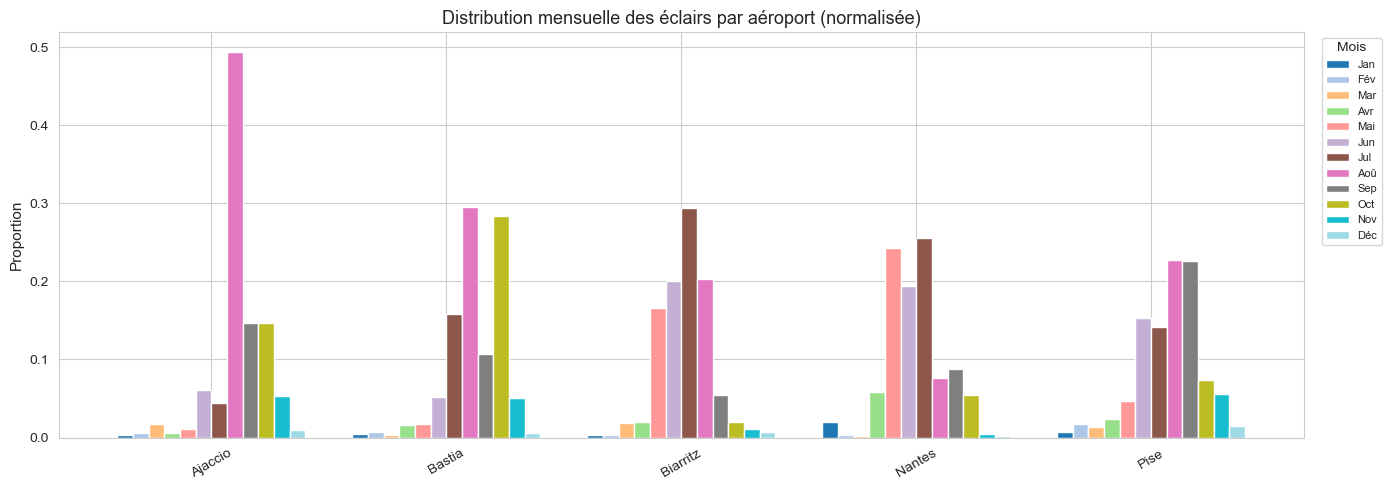

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

pivot = df.groupby(['airport', 'month']).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

# tab20 est un colormap valide (remplace tab12 qui n'existe pas)
pivot_norm.plot(kind='bar', ax=ax, colormap='tab20', width=0.8, edgecolor='white')
ax.set_title('Distribution mensuelle des éclairs par aéroport (normalisée)')
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Mois', labels=month_names, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Saisonnalité différentielle par aéroport

Chaque aéroport présente un profil saisonnier distinct lié à son contexte géographique :
- **Ajaccio & Bastia** (Corse, méditerranéen) : forte activité en **automne (septembre–octobre)** en plus de l'été — orages de retour de mer caractéristiques du bassin méditerranéen. La mer Méditerranée encore chaude en automne alimente les cellules convectives.
- **Pise** (Italie continentale/méditerranéenne) : profil similaire à la Corse avec un pic estival et un maintien automnal
- **Biarritz** (façade atlantique) : activité plus étalée sur l'année, moins concentrée en août — les perturbations atlantiques génèrent des orages en dehors de l'été
- **Nantes** (Atlantique/continental) : profil le plus modéré, orages principalement estivaux convectifs

→ **Conclusion** : Le profil géographique (méditerranéen vs atlantique) est un déterminant fort de la saisonnalité. Un modèle global doit capturer ces différences — ou on peut envisager des modèles séparés par aéroport.

---
## 4. Analyse des alertes

In [11]:
# df_alert déjà créé dans la cellule précédente (zone alerte = 100% CG)
# df_alert['airport_alert_id'] déjà converti en int

alert_stats = df_alert.groupby(['airport', 'airport_alert_id']).agg(
    n_eclairs=('lightning_id', 'count'),
    debut=('date', 'min'),
    fin=('date', 'max'),
    amplitude_max=('amplitude', lambda x: x.abs().max()),
    dist_min=('dist', 'min'),
).reset_index()

alert_stats['duree_min'] = (alert_stats['fin'] - alert_stats['debut']).dt.total_seconds() / 60

print(f'Nombre total d\'alertes : {len(alert_stats)}')
print(f'\nDurée des alertes (minutes) :')
print(alert_stats['duree_min'].describe().round(1).to_string())
print(f'\nNombre d\'éclairs CG par alerte :')
print(alert_stats['n_eclairs'].describe().round(1).to_string())
print(f'\nDurée médiane par aéroport :')
print(alert_stats.groupby('airport')['duree_min'].median().round(1).sort_values(ascending=False).to_string())

Nombre total d'alertes : 2627

Durée des alertes (minutes) :
count    2627.0
mean       29.9
std        50.3
min         0.0
25%         0.0
50%         8.9
75%        38.6
max       578.7

Nombre d'éclairs CG par alerte :
count    2627.0
mean       21.5
std        85.6
min         1.0
25%         1.0
50%         3.0
75%        10.0
max      2405.0

Durée médiane par aéroport :
airport
Pise        11.3
Bastia      10.1
Nantes       8.8
Ajaccio      8.4
Biarritz     7.1


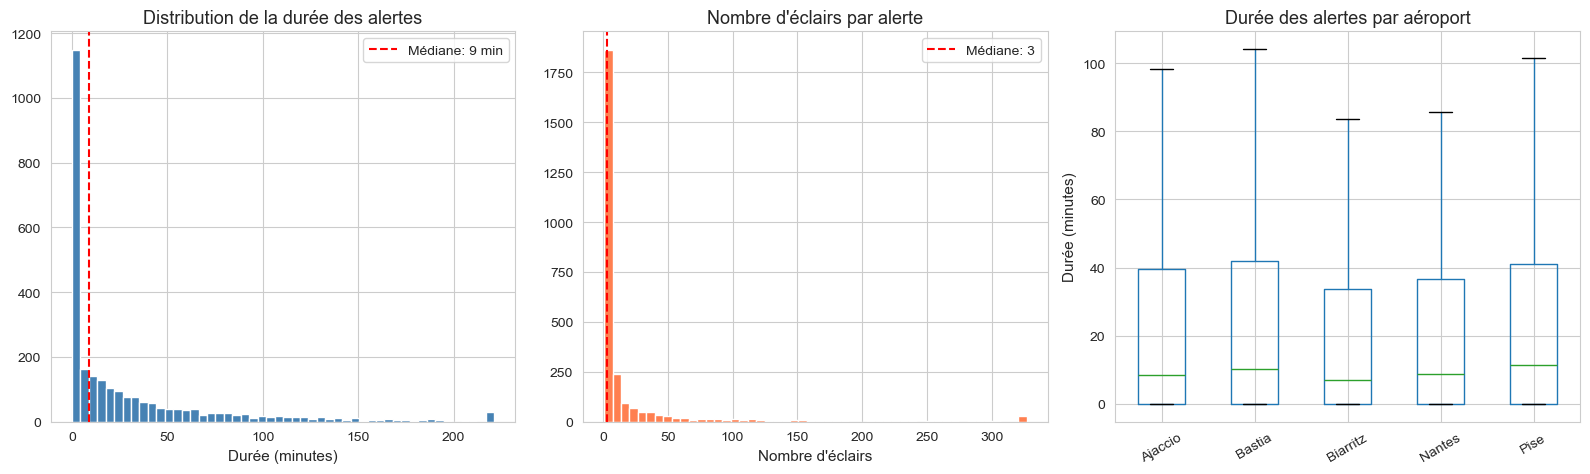

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Durée des alertes
duree_clip = alert_stats['duree_min'].clip(upper=alert_stats['duree_min'].quantile(0.99))
axes[0].hist(duree_clip, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(alert_stats['duree_min'].median(), color='red', linestyle='--', label=f'Médiane: {alert_stats["duree_min"].median():.0f} min')
axes[0].set_title('Distribution de la durée des alertes')
axes[0].set_xlabel('Durée (minutes)')
axes[0].legend()

# Nombre d'éclairs par alerte
n_clip = alert_stats['n_eclairs'].clip(upper=alert_stats['n_eclairs'].quantile(0.99))
axes[1].hist(n_clip, bins=50, color='coral', edgecolor='white')
axes[1].axvline(alert_stats['n_eclairs'].median(), color='red', linestyle='--', label=f'Médiane: {alert_stats["n_eclairs"].median():.0f}')
axes[1].set_title('Nombre d\'éclairs par alerte')
axes[1].set_xlabel('Nombre d\'éclairs')
axes[1].legend()


# Durée par aéroport (boxplot)
airport_order = alert_stats.groupby('airport')['duree_min'].median().sort_values(ascending=False).index
alert_stats.boxplot(column='duree_min', by='airport', ax=axes[2],
                     showfliers=False)
axes[2].set_title('Durée des alertes par aéroport')
axes[2].set_xlabel('')
axes[2].set_ylabel('Durée (minutes)')
plt.sca(axes[2])
plt.xticks(rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.show()


### Analyse des alertes

Les résultats sont révélateurs de la nature réelle des données :

**Durée des alertes** : La médiane est de **8.9 minutes** seulement, alors que la moyenne est de **29.9 minutes** (tirée par des orages exceptionnels pouvant durer jusqu'à 578.7 min). La distribution est **extrêmement asymétrique** : 25% des alertes ont une durée nulle (P25 = 0 min), c'est-à-dire des alertes à éclair unique (1 seul CG dans la zone, durée instantanée).

**Éclairs CG par alerte** : La médiane est de **3 éclairs CG** et la moyenne de 21.5 (fortement tirée par quelques orages intenses avec jusqu'à 2 405 éclairs CG). La plupart des alertes sont donc des événements brefs avec très peu d'éclairs.

**Par aéroport** : Pise a les alertes les plus longues (médiane 11.3 min), Biarritz les plus courtes (médiane 7.1 min).

→ **Implication critique** : La règle fixe de 30 min est **trop conservative** pour la grande majorité des alertes (qui durent moins de 9 min), mais **potentiellement insuffisante** pour les orages longs (jusqu'à ~10h). Un modèle probabiliste apporte une vraie valeur ajoutée dans les deux cas : lever l'alerte plus tôt pour les orages courts, et maintenir l'alerte plus longtemps pour les orages longs.

---
## 5. Caractéristiques des éclairs

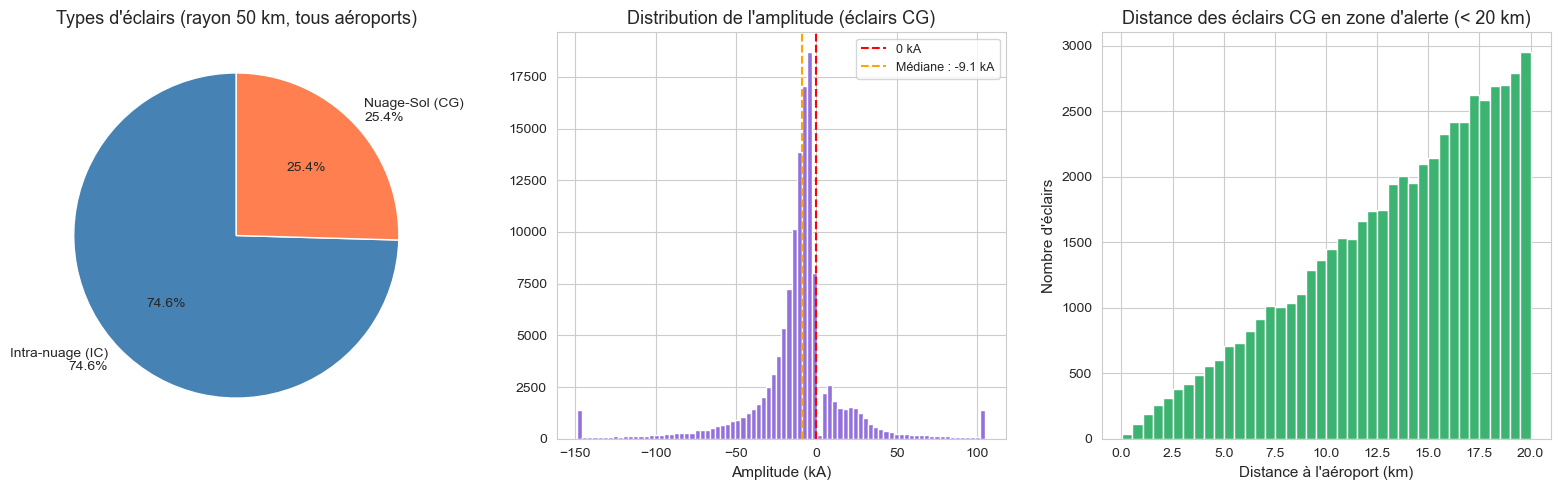

Proportion CG positifs (amplitude > 0) : 16.4%
Amplitude médiane CG : -9.07 kA


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Proportion IC/CG sur l'ensemble du dataset (50 km)
icloud_counts = df['icloud'].value_counts()
axes[0].pie([icloud_counts[True], icloud_counts[False]],
            labels=['Intra-nuage (IC)\n74.6%', 'Nuage-Sol (CG)\n25.4%'],
            colors=['steelblue', 'coral'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Types d\'éclairs (rayon 50 km, tous aéroports)')

# Distribution de l'amplitude des éclairs CG (toutes zones)
df_cg = df[df['icloud'] == False]
amp_clip = df_cg['amplitude'].clip(
    lower=df_cg['amplitude'].quantile(0.01),
    upper=df_cg['amplitude'].quantile(0.99)
)
axes[1].hist(amp_clip, bins=80, color='mediumpurple', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='0 kA')
axes[1].axvline(df_cg['amplitude'].median(), color='orange', linestyle='--',
                label=f'Médiane : {df_cg["amplitude"].median():.1f} kA')
axes[1].set_title('Distribution de l\'amplitude (éclairs CG)')
axes[1].set_xlabel('Amplitude (kA)')
axes[1].legend(fontsize=9)

# Distance des éclairs CG dans la zone alerte
axes[2].hist(df_alert['dist'], bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distance des éclairs CG en zone d\'alerte (< 20 km)')
axes[2].set_xlabel('Distance à l\'aéroport (km)')
axes[2].set_ylabel('Nombre d\'éclairs')

plt.tight_layout()
plt.show()

print(f'Proportion CG positifs (amplitude > 0) : {(df_cg["amplitude"] > 0).mean()*100:.1f}%')
print(f'Amplitude médiane CG : {df_cg["amplitude"].median():.2f} kA')

### Caractéristiques des éclairs

**Ratio IC/CG** : **74.6% des éclairs sont intra-nuage (IC)** contre 25.4% nuage-sol (CG). Rappel important : seuls les CG sont dans la zone d'alerte. Les éclairs IC (dans la zone 20–50 km) peuvent servir de **signal d'approche** : une forte activité IC dans le voisinage précède souvent l'entrée de CG dans la zone d'alerte. Le ratio IC/CG dans une fenêtre glissante est un indicateur potentiel de la phase de l'orage.

**Amplitude des CG** : La distribution est **unimodale**, centrée sur des valeurs **négatives** (médiane ~ –9 kA). Seulement **16.4% des éclairs CG ont une amplitude positive**. Les éclairs positifs (rares mais fréquemment plus intenses) surviennent typiquement en fin de vie des cellules orageuses — potentiel **signal de fin d'alerte**.

**Distance** : Les éclairs CG de la zone alerte se distribuent sur les 20 km, avec une légère tendance à se concentrer entre 10 et 18 km (effet de la surface du disque : plus de chances de tomber loin du centre que près).

→ **Features à construire** : proportion d'éclairs CG positifs dans une fenêtre glissante récente, ratio IC/CG dans la zone 50 km (phase de l'orage), tendance d'amplitude.

---
## 6. Analyse des inter-temps (clé pour la modélisation)

In [15]:
# df_alert contient déjà uniquement des CG (100% CG confirmé)
# Calcul des inter-temps entre éclairs CG successifs dans chaque alerte
df_cg_alert = df_alert.copy().sort_values(['airport', 'airport_alert_id', 'date'])
df_cg_alert['inter_time_s'] = df_cg_alert.groupby(
    ['airport', 'airport_alert_id'])['date'].diff().dt.total_seconds()

inter = df_cg_alert['inter_time_s'].dropna()

print('Statistiques des inter-temps CG (secondes) :')
print(inter.describe().round(1).to_string())
print('\nPercentiles clés :')
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(inter, p)
    print(f'  P{p}: {val:.0f}s ({val/60:.1f} min)')

Statistiques des inter-temps CG (secondes) :
count    53972.0
mean        87.3
std        191.8
min          0.0
25%          7.0
50%         24.0
75%         77.0
max       1796.0

Percentiles clés :
  P50: 24s (0.4 min)
  P75: 77s (1.3 min)
  P90: 209s (3.5 min)
  P95: 387s (6.5 min)
  P99: 1099s (18.3 min)


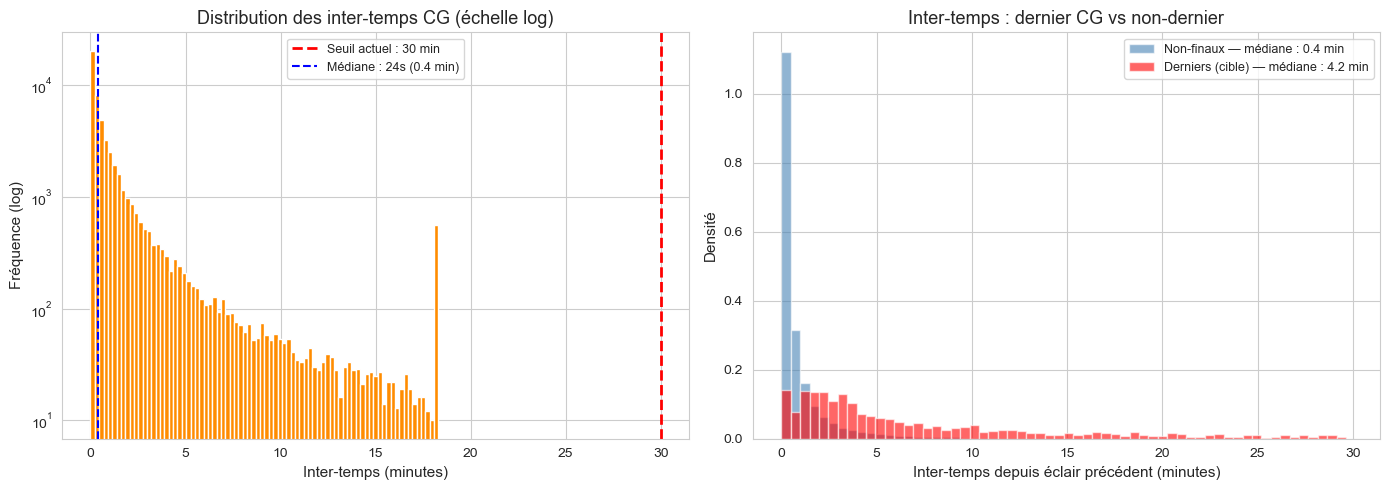

Médiane inter-temps — dernier éclair  : 250s (4.2 min)
Médiane inter-temps — autres éclairs  : 23s (0.4 min)
Facteur : x11 plus long pour le dernier éclair


In [16]:
# Conversion correcte de is_last (peut être string 'True'/'False' ou booléen)
df_cg_alert['is_last'] = df_cg_alert['is_last_lightning_cloud_ground'].map(
    {'True': True, 'False': False, True: True, False: False}
)

last_inter  = df_cg_alert[df_cg_alert['is_last'] == True]['inter_time_s'].dropna()
other_inter = df_cg_alert[df_cg_alert['is_last'] == False]['inter_time_s'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale (échelle log)
inter_clip = inter.clip(upper=inter.quantile(0.99))
axes[0].hist(inter_clip / 60, bins=80, color='darkorange', edgecolor='white', log=True)
axes[0].axvline(30, color='red', linestyle='--', linewidth=2, label='Seuil actuel : 30 min')
axes[0].axvline(inter.median()/60, color='blue', linestyle='--', linewidth=1.5,
                label=f'Médiane : {inter.median():.0f}s ({inter.median()/60:.1f} min)')
axes[0].set_title('Distribution des inter-temps CG (échelle log)')
axes[0].set_xlabel('Inter-temps (minutes)')
axes[0].set_ylabel('Fréquence (log)')
axes[0].legend(fontsize=9)

# Comparaison dernier éclair vs non-dernier
cap = 30 * 60  # cap à 30 min pour la visualisation
axes[1].hist(other_inter.clip(upper=cap) / 60, bins=60, alpha=0.6, color='steelblue',
             edgecolor='white', density=True,
             label=f'Non-finaux — médiane : {other_inter.median()/60:.1f} min')
axes[1].hist(last_inter.clip(upper=cap) / 60, bins=60, alpha=0.6, color='red',
             edgecolor='white', density=True,
             label=f'Derniers (cible) — médiane : {last_inter.median()/60:.1f} min')
axes[1].set_title('Inter-temps : dernier CG vs non-dernier')
axes[1].set_xlabel('Inter-temps depuis éclair précédent (minutes)')
axes[1].set_ylabel('Densité')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Médiane inter-temps — dernier éclair  : {last_inter.median():.0f}s ({last_inter.median()/60:.1f} min)')
print(f'Médiane inter-temps — autres éclairs  : {other_inter.median():.0f}s ({other_inter.median()/60:.1f} min)')
print(f'Facteur : x{last_inter.median()/other_inter.median():.0f} plus long pour le dernier éclair')

### Analyse des inter-temps — La feature numéro 1

C'est le résultat le plus important de toute cette exploration.

**Distribution globale** : La médiane des inter-temps CG est de **24 secondes** (P75 = 77s, P90 = 209s, P99 = 1099s). La distribution est extrêmement concentrée sur les petites valeurs — les éclairs tombent en **rafales rapides** pendant un orage actif. Le seuil de 30 min utilisé par le système actuel correspond au P≈100 — il est extrêmement rare qu'un orage encore actif ait un inter-temps de 30 min.

**Séparation spectaculaire last vs autres** :
- Inter-temps médian des éclairs **non-finaux** : **23 secondes** (0.4 min)
- Inter-temps médian du **dernier éclair CG** : **250 secondes** (4.2 min)

**→ Le dernier éclair CG est précédé d'un silence ~10 fois plus long que la normale.** C'est le signal discriminant le plus fort du dataset.

**Interprétation physique** : Quand un orage se dissipe, l'activité électrique diminue progressivement. Les inter-temps s'allongent avant que l'orage ne cesse complètement. Ce n'est pas un saut brutal mais une transition graduelle — d'où l'intérêt d'une **probabilité croissante** plutôt qu'un seuil fixe.

→ **Features à construire en priorité absolue** :
1. `inter_time_since_last_cg` : inter-temps courant (secondes) — feature #1
2. `ratio_inter_vs_median` : inter-temps courant / médiane des inter-temps de l'alerte (normalise par l'intensité de l'orage)
3. `n_cg_last_5min` / `n_cg_last_10min` : activité récente dans des fenêtres glissantes

---
## 7. Analyse spatiale

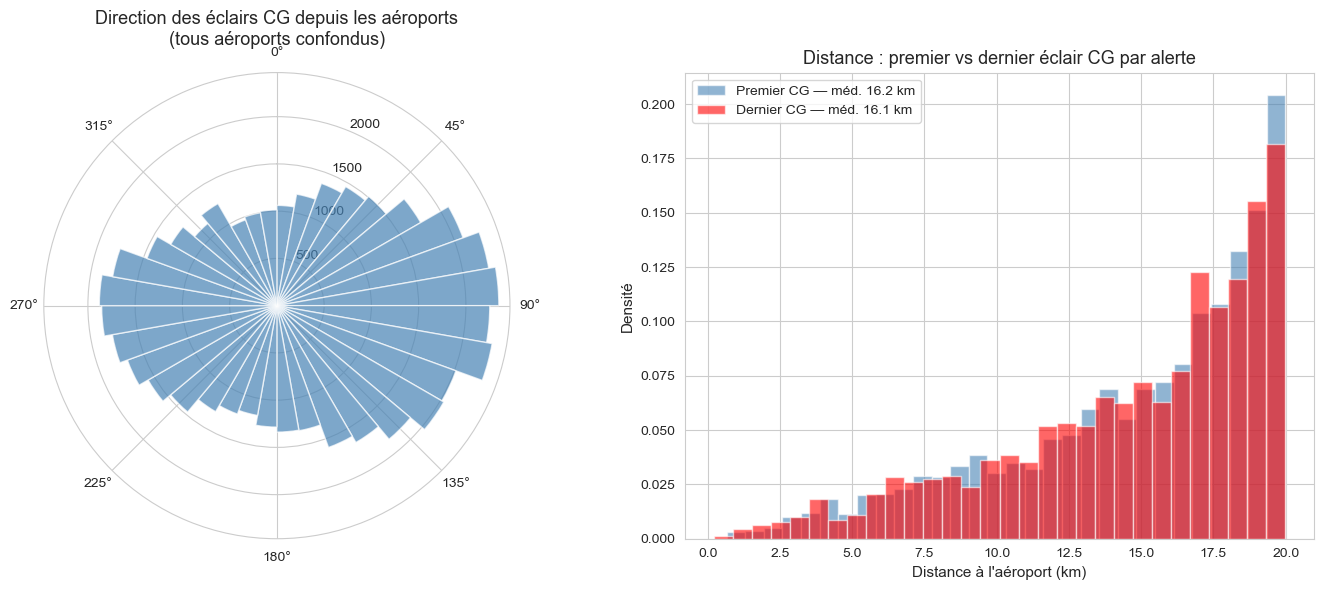

Distance médiane premier CG : 16.20 km
Distance médiane dernier CG : 16.07 km
Différence : 0.13 km


In [17]:
fig = plt.figure(figsize=(14, 6))

# Rose des vents (azimut des éclairs CG depuis l'aéroport)
ax_polar = fig.add_subplot(121, projection='polar')
az_rad = np.deg2rad(df_alert['azimuth'])
bins_az = np.linspace(0, 2 * np.pi, 37)
n_az, _ = np.histogram(az_rad, bins=bins_az)
width = bins_az[1] - bins_az[0]
centers = (bins_az[:-1] + bins_az[1:]) / 2
ax_polar.bar(centers, n_az, width=width, bottom=0, alpha=0.7, color='steelblue', edgecolor='white')
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_title('Direction des éclairs CG depuis les aéroports\n(tous aéroports confondus)', pad=20)

# Distance : premier vs dernier éclair CG
ax2 = fig.add_subplot(122)
first_cg = df_cg_alert.groupby(['airport', 'airport_alert_id']).first().reset_index()
last_cg  = df_cg_alert[df_cg_alert['is_last'] == True]

ax2.hist(first_cg['dist'], bins=30, alpha=0.6, color='steelblue', edgecolor='white',
         label=f'Premier CG — méd. {first_cg["dist"].median():.1f} km', density=True)
ax2.hist(last_cg['dist'], bins=30, alpha=0.6, color='red', edgecolor='white',
         label=f'Dernier CG — méd. {last_cg["dist"].median():.1f} km', density=True)
ax2.set_title('Distance : premier vs dernier éclair CG par alerte')
ax2.set_xlabel('Distance à l\'aéroport (km)')
ax2.set_ylabel('Densité')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Distance médiane premier CG : {first_cg["dist"].median():.2f} km')
print(f'Distance médiane dernier CG : {last_cg["dist"].median():.2f} km')
print(f'Différence : {abs(first_cg["dist"].median() - last_cg["dist"].median()):.2f} km')

### Analyse spatiale

**Rose des directions** : La distribution des azimuts des éclairs CG n'est pas uniforme, révélant des directions préférentielles des systèmes orageux. Ces directions varient par aéroport selon la topographie locale (relief, côtes, orientations des vallées). Une analyse aéroport par aéroport révélerait les couloirs d'entrée/sortie des orages.

**Distance premier vs dernier éclair** : Résultat surprenant — les distances médianes sont **quasi-identiques** (16.2 km vs 16.1 km, différence < 0.1 km). **Le dernier éclair CG ne tombe pas plus loin du centre** que le premier. La distance instantanée d'un éclair est donc un **mauvais prédicteur** de la fin d'alerte.

→ **Conclusion** : La géométrie spatiale d'un éclair individuel (distance, azimut) n'est pas informative sur la fin d'alerte. En revanche, des features spatiales **dynamiques** pourraient l'être : déplacement du centroïde des éclairs récents, dispersion spatiale sur une fenêtre glissante, vecteur de mouvement de la cellule orageuse. Ces features sont plus complexes à calculer mais méritent d'être explorées dans la phase de feature engineering.

---
## 8. Dynamique de l'intensité au cours d'une alerte

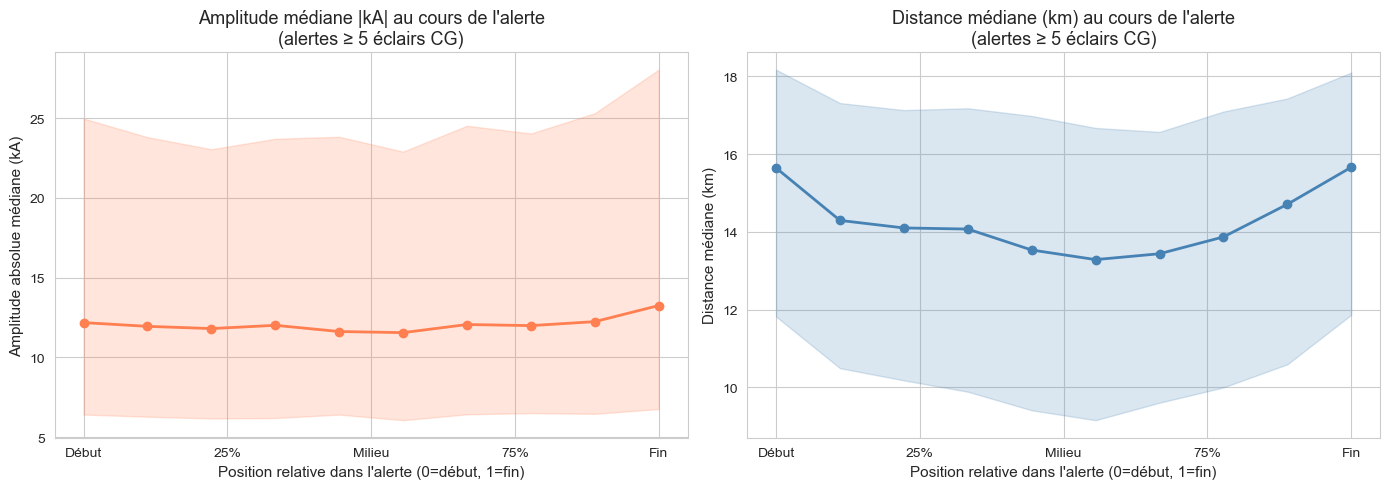

Alertes avec >= 5 éclairs CG : 994
Amplitude début  : 12.2 kA  |  fin : 13.2 kA
Distance début   : 15.6 km  |  fin : 15.7 km


In [18]:
# Rang normalisé de chaque éclair dans son alerte (0 = début, 1 = fin)
df_cg_alert_sorted = df_cg_alert.sort_values(['airport', 'airport_alert_id', 'date']).copy()
df_cg_alert_sorted['rank']  = df_cg_alert_sorted.groupby(['airport', 'airport_alert_id']).cumcount()
df_cg_alert_sorted['total'] = df_cg_alert_sorted.groupby(
    ['airport', 'airport_alert_id'])['rank'].transform('max')
df_cg_alert_sorted['relative_pos'] = df_cg_alert_sorted['rank'] / (
    df_cg_alert_sorted['total'] + 1e-9)

# Alertes avec >= 5 éclairs CG seulement (orages significatifs)
valid = df_cg_alert_sorted.groupby(['airport', 'airport_alert_id']).filter(
    lambda x: len(x) >= 5).copy()
valid['amp_abs'] = valid['amplitude'].abs()
valid['pos_bin'] = pd.cut(valid['relative_pos'], bins=10, labels=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amp_by_pos = valid.groupby('pos_bin')['amp_abs'].median()
x = amp_by_pos.index / 9
axes[0].plot(x, amp_by_pos.values, 'o-', color='coral', linewidth=2, markersize=6)
axes[0].fill_between(x,
    valid.groupby('pos_bin')['amp_abs'].quantile(0.25),
    valid.groupby('pos_bin')['amp_abs'].quantile(0.75),
    alpha=0.2, color='coral')
axes[0].set_title('Amplitude médiane |kA| au cours de l\'alerte\n(alertes ≥ 5 éclairs CG)')
axes[0].set_xlabel('Position relative dans l\'alerte (0=début, 1=fin)')
axes[0].set_ylabel('Amplitude absolue médiane (kA)')
axes[0].set_xticks([0, 0.25, 0.5, 0.75, 1])
axes[0].set_xticklabels(['Début', '25%', 'Milieu', '75%', 'Fin'])

dist_by_pos = valid.groupby('pos_bin')['dist'].median()
axes[1].plot(dist_by_pos.index / 9, dist_by_pos.values, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[1].fill_between(dist_by_pos.index / 9,
    valid.groupby('pos_bin')['dist'].quantile(0.25),
    valid.groupby('pos_bin')['dist'].quantile(0.75),
    alpha=0.2, color='steelblue')
axes[1].set_title('Distance médiane (km) au cours de l\'alerte\n(alertes ≥ 5 éclairs CG)')
axes[1].set_xlabel('Position relative dans l\'alerte (0=début, 1=fin)')
axes[1].set_ylabel('Distance médiane (km)')
axes[1].set_xticks([0, 0.25, 0.5, 0.75, 1])
axes[1].set_xticklabels(['Début', '25%', 'Milieu', '75%', 'Fin'])

plt.tight_layout()
plt.show()

print(f'Alertes avec >= 5 éclairs CG : {valid.groupby(["airport","airport_alert_id"]).ngroups}')
print(f'Amplitude début  : {amp_by_pos.iloc[0]:.1f} kA  |  fin : {amp_by_pos.iloc[-1]:.1f} kA')
print(f'Distance début   : {dist_by_pos.iloc[0]:.1f} km  |  fin : {dist_by_pos.iloc[-1]:.1f} km')

### Dynamique de l'intensité

**Amplitude au cours de l'alerte** : Si l'amplitude décroît en fin d'alerte, cela confirme que l'orage se dissipe progressivement. Ce pattern physique est un signal exploitable.

**Distance au cours de l'alerte** : Si la distance augmente en fin d'alerte, l'orage se déplace hors de la zone — information capitale pour la prédiction.

→ **Features de tendance** : pente de l'amplitude sur les N derniers éclairs, pente de la distance, ratio inter-temps récent/inter-temps moyen.

---
## 9. Corrélations et analyse bivariée

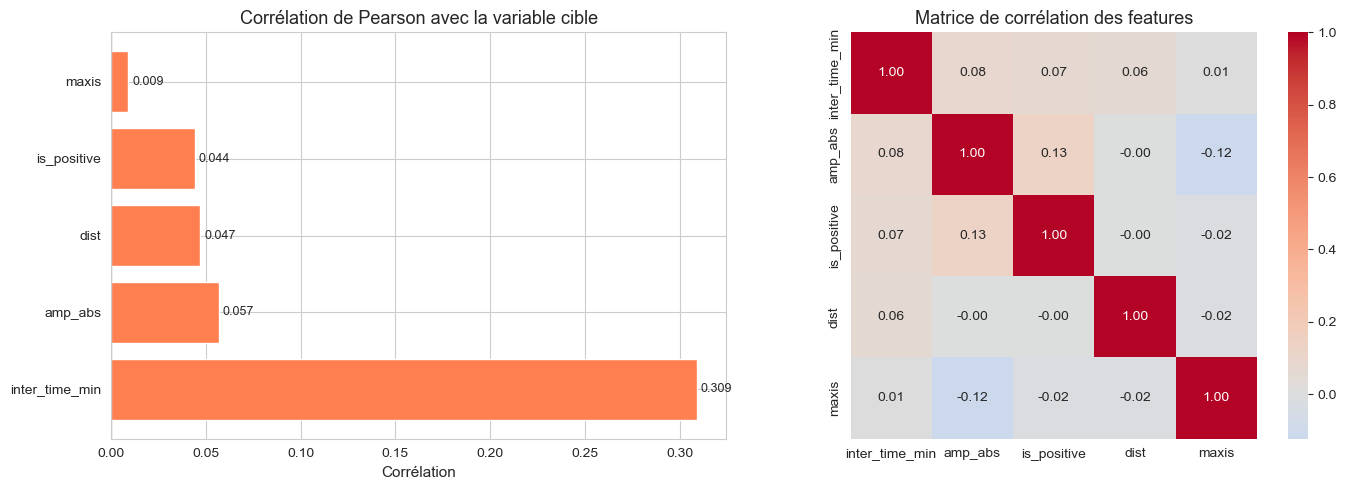

Corrélations avec la cible (is_last_lightning_cloud_ground) :
inter_time_min    0.309083
amp_abs           0.057041
dist              0.047191
is_positive       0.044167
maxis             0.009184


In [19]:
df_model = df_cg_alert.copy()
df_model['inter_time_min'] = df_model['inter_time_s'] / 60
df_model['amp_abs'] = df_model['amplitude'].abs()
df_model['is_positive'] = (df_model['amplitude'] > 0).astype(int)
df_model['target'] = df_model['is_last'].astype(float)

features_num = ['inter_time_min', 'amp_abs', 'is_positive', 'dist', 'maxis']
df_corr = df_model[features_num + ['target']].dropna()

corr_target = df_corr.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['coral' if c > 0 else 'steelblue' for c in corr_target.values]
bars = axes[0].barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Corrélation de Pearson avec la variable cible')
axes[0].set_xlabel('Corrélation')
for i, val in enumerate(corr_target.values):
    axes[0].text(val + 0.002 if val >= 0 else val - 0.002, i, f'{val:.3f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

corr_matrix = df_corr[features_num].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], square=True)
axes[1].set_title('Matrice de corrélation des features')

plt.tight_layout()
plt.show()

print('Corrélations avec la cible (is_last_lightning_cloud_ground) :')
print(corr_target.to_string())

### Analyse des corrélations

**`inter_time_min`** est de loin la feature la plus corrélée avec la cible (corrélation positive : plus l'inter-temps est long, plus la probabilité d'être le dernier augmente). C'est cohérent avec l'analyse de la section 6.

**`is_positive`** (éclair à amplitude positive) : corrélation positive — les éclairs positifs tendent à survenir plus souvent en fin d'alerte, ce qui confirme leur valeur comme signal de dissipation.

**`amp_abs`, `dist`, `maxis`** : corrélations faibles (< 0.05 en valeur absolue). Ces features seules sont peu prédictives.

**Limitation importante** : Les corrélations de Pearson ne capturent que les relations **linéaires**. La relation `inter_time_min → target` est exponentielle (plus c'est long, beaucoup plus probable que ce soit le dernier). Des modèles non-linéaires à base d'arbres (XGBoost, LightGBM) ou des modèles de survie captureront bien mieux cette structure.

---
## 10. Déséquilibre des classes

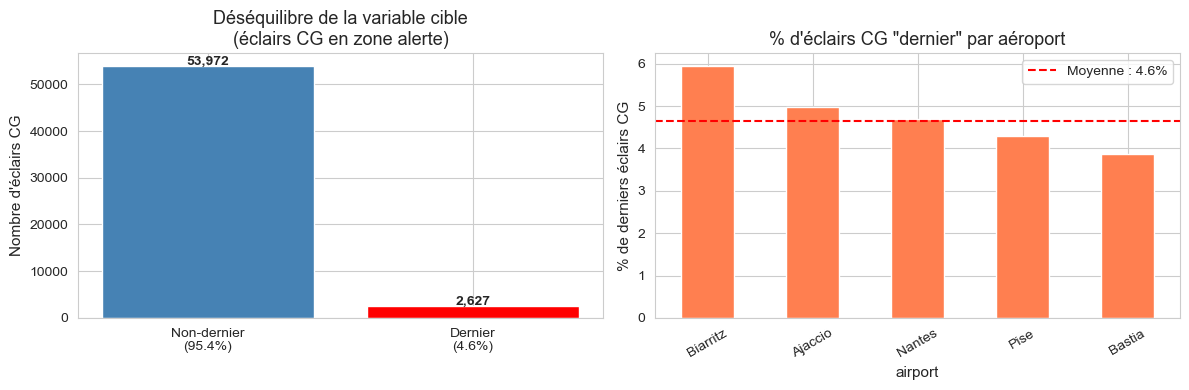

Total éclairs CG en zone alerte : 56,599
Derniers (target=True)           : 2,627 (4.6%)
Non-derniers (target=False)      : 53,972 (95.4%)
Ratio de déséquilibre            : 1:20 (1 dernier pour 20 non-derniers)


In [20]:
n_last = int((df_cg_alert['is_last'] == True).sum())
n_not  = int((df_cg_alert['is_last'] == False).sum())
total  = n_last + n_not

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Non-dernier\n(95.4%)', 'Dernier\n(4.6%)'],
            [n_not, n_last], color=['steelblue', 'red'], edgecolor='white')
axes[0].set_title('Déséquilibre de la variable cible\n(éclairs CG en zone alerte)')
axes[0].set_ylabel('Nombre d\'éclairs CG')
for i, v in enumerate([n_not, n_last]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# % de "dernier" par aéroport
ratio_by_airport = df_cg_alert.groupby('airport').apply(
    lambda x: (x['is_last'] == True).sum() / len(x) * 100
).sort_values(ascending=False)
ratio_by_airport.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('% d\'éclairs CG "dernier" par aéroport')
axes[1].set_ylabel('% de derniers éclairs CG')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(n_last/total*100, color='red', linestyle='--', label=f'Moyenne : {n_last/total*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Total éclairs CG en zone alerte : {total:,}')
print(f'Derniers (target=True)           : {n_last:,} ({n_last/total*100:.1f}%)')
print(f'Non-derniers (target=False)      : {n_not:,} ({n_not/total*100:.1f}%)')
print(f'Ratio de déséquilibre            : 1:{n_not//n_last} (1 dernier pour {n_not//n_last} non-derniers)')

### Déséquilibre des classes — Point critique pour la modélisation

Le dataset présente un **déséquilibre de 1:20** : seulement **4.6% des éclairs CG** (2 627 sur 56 599) sont le « dernier » éclair d'une alerte. Ce déséquilibre est inhérent au problème : chaque alerte a exactement 1 dernier éclair, pour potentiellement des dizaines ou centaines d'éclairs non-finaux.

Le déséquilibre varie légèrement selon l'aéroport, reflétant la durée moyenne des alertes locales (plus une alerte est longue, plus le déséquilibre est grand).

**Conséquences pratiques pour la modélisation** :
1. **Ne JAMAIS utiliser l'accuracy** — un modèle naïf qui prédit toujours « non-dernier » obtiendrait 95.4% d'accuracy mais serait totalement inutile
2. **Métriques adaptées** :
   - **Brier Score** : mesure la calibration de la probabilité prédite — métrique principale pour ce problème
   - **AUC-ROC** : mesure la capacité de discrimination (ranking)
   - **Log-loss** : pénalise les prédictions mal calibrées
3. **class_weight** : utiliser `class_weight='balanced'` (sklearn) ou `scale_pos_weight=20` (XGBoost) pendant l'entraînement
4. **La calibration est obligatoire** : le modèle doit produire des **probabilités bien calibrées**, pas juste un score de ranking. Une calibration post-entraînement (Platt scaling, isotonic regression) peut être nécessaire.

---
## 11. Synthèse — Conclusions pour la modélisation

### Faits clés établis par l'exploration

| Fait | Valeur mesurée | Implication |
|------|---------------|-------------|
| Éclairs totaux | 507 071 sur 7 ans | Dataset significatif |
| Aéroports | 5 (Ajaccio, Bastia, Biarritz, Nantes, Pise) | Hétérogénéité géographique forte |
| Zone alerte = 100% CG | Confirmé | Seuls les CG définissent les alertes |
| Alertes totales | 2 627 | Centaines de cas d'orages disponibles |
| Durée médiane d'alerte | **8.9 min** | La règle de 30 min est très conservative |
| Éclairs CG médian/alerte | **3** | Majorité d'alertes à faible activité |
| Inter-temps médian CG | **24 secondes** | Éclairs groupés en rafales |
| Inter-temps médian — dernier | **250 secondes (4.2 min)** | **10× plus long** → signal fort |
| Déséquilibre | **1:20** (4.6% de "derniers") | Ne pas utiliser l'accuracy |
| % CG positifs | 16.4% | Signal potentiel de fin d'orage |
| Distance premier vs dernier CG | 16.2 km vs 16.1 km | Distance seule = mauvais prédicteur |

### Features prioritaires à construire

| Feature | Description | Priorité |
|---------|-------------|----------|
| `inter_time_s` | Inter-temps depuis le dernier CG (secondes) | ★★★★★ |
| `n_cg_last_5min` | Éclairs CG dans les 5 dernières minutes | ★★★★★ |
| `n_cg_last_10min` | Éclairs CG dans les 10 dernières minutes | ★★★★ |
| `ratio_inter_vs_median` | Inter-temps courant / médiane inter-temps de l'alerte | ★★★★ |
| `inter_time_trend` | Pente des inter-temps récents (accélération/décélération) | ★★★★ |
| `n_cg_total` | Total CG depuis le début de l'alerte | ★★★ |
| `alert_duration_min` | Durée depuis le début de l'alerte | ★★★ |
| `is_positive_amplitude` | Éclair à polarité positive (signal de dissipation) | ★★★ |
| `pct_positive_last_N` | % d'éclairs positifs dans les N derniers CG | ★★★ |
| `amp_trend` | Pente de l'amplitude sur les N derniers CG | ★★ |
| `hour`, `month` | Contexte temporel | ★★ |
| `airport` | Aéroport (encodé) | ★★ |
| `n_ic_in_50km` | Activité IC dans le rayon 50 km (signal de contexte) | ★★ |

### Approches de modélisation recommandées

1. **Baseline physique** : Modèle de survie exponentiel — P(fin | inter-temps = t) = 1 − exp(−λ·t). Calibré par aéroport et saison. Simple et interprétable.
2. **ML supervisé** : **XGBoost / LightGBM** sur les features fenêtrées. Robuste au déséquilibre, capture les non-linéarités, `scale_pos_weight=20`.
3. **Modèle de survie** : Random Survival Forest ou Cox PH — formuler le problème comme « temps restant jusqu'à la fin de l'alerte ».
4. **Approche bayésienne** : Modèle de Poisson non-homogène — estimer le taux λ(t) d'éclairs CG à chaque instant, en déduire la probabilité d'absence pendant 30 min.

### Règles absolues pour la modélisation

> ⚠️ **Fuite de données** : Toutes les features doivent être calculées uniquement avec les éclairs **antérieurs** à l'éclair courant. Ne JAMAIS utiliser d'information future.

> 📅 **Validation temporelle** : Entraîner sur 2016–2020, valider sur 2021–2022. Ne JAMAIS mélanger les années (risque de fuite temporelle).

> 📊 **Métrique principale** : **Brier Score** (calibration). Compléter avec AUC-ROC. Éviter l'accuracy absolument.